<a href="https://colab.research.google.com/github/LauraPazGOT/Desafio-TelecomX-2parte/blob/main/DesafioTelecomX2parte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📚 Librerias a Utilizar en Proyecto

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


## 🔍 Carga de DataFrame

In [3]:
df = pd.read_csv("/content/datos_tratados_telecomx.csv")
df.head(2)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,account.Charges.Daily
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667


In [5]:
df.shape

(7043, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   objec

In [6]:
df.isna().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [7]:
# Removemos informacion innecesaria como customerID
df = df.drop(columns='customerID')
df.columns


Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total',
       'account.Charges.Daily'],
      dtype='object')

In [8]:
# Limpieza de variable numérica mal tipada
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Eliminamos registros donde no se pudo convertir
df = df.dropna(subset=['account.Charges.Total'])

In [9]:
df['account.Charges.Total'].isna().sum()

np.int64(0)

## 🎯 Preparación del target

In [10]:
# Convertir la variable objetivo Churn a binaria
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verificar la transformación
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


## 📂 Seperacion de Variable dependiente del Resto del conjunto de datos

In [11]:
X = df.drop(['Churn'],axis=1)
y = df['Churn']

In [12]:
# Dividir primero (con estratificacion)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## 🔢 Codificación de variables categóricas

In [13]:
# Columnas binarias (Yes/No)
columnas_binarias = [
    'customer.Partner', 'customer.Dependents', 'phone.PhoneService',
    'phone.MultipleLines', 'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV',
    'internet.StreamingMovies', 'account.PaperlessBilling'
]

In [14]:
# Diccionario completo de conversión binaria
map_binario = {
    'Yes': 1,
    'No': 0,
    'No internet service': 0,
    'No phone service': 0
}


In [15]:
# Aplicamos la conversión SOLO al train
for col in columnas_binarias:
    X_train[col] = X_train[col].map(map_binario)

In [16]:
# Aplicamos la misma transformación al test
for col in columnas_binarias:
    X_test[col] = X_test[col].map(map_binario)

In [17]:
# Verificación: aseguramos que no queden valores faltantes
print("NaN en X_train:", X_train.isna().sum().sum())
print("NaN en X_test:", X_test.isna().sum().sum())

NaN en X_train: 0
NaN en X_test: 0


In [19]:
# Columnas categóricas con múltiples opciones
columnas_multiple_opcion = [
    'customer.gender',
    'internet.InternetService',
    'account.Contract',
    'account.PaymentMethod'
]

In [20]:
# Aplicamos One-Hot Encoding a las columnas multiple opcion
X_train = pd.get_dummies(X_train, columns=columnas_multiple_opcion, drop_first=True)
X_test = pd.get_dummies(X_test, columns=columnas_multiple_opcion, drop_first=True)

# Alinear columnas ya que en TRAIN puede aparecer una categoría que en TEST no existe o viceversa.
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [21]:
# Revisar la forma del nuevo DataFrame
print(X_train.shape, X_test.shape)

(5625, 24) (1407, 24)


In [22]:
# Proporción de churn
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498


"Se verificó que el dataset presenta un desbalance moderado (73/27), considerado aceptable, por lo que no se aplicaron técnicas de balanceo."

In [23]:
# Construimos un DF de análisis con el train y el target
df_train = X_train.copy()
df_train['Churn'] = y_train

In [24]:
# Crear matriz de correlación completa
corr = X_train.copy()
corr['Churn'] = y_train

corr = corr.corr(numeric_only=True)

In [25]:
# Tomamos solo correlaciones con Churn
corr_churn = corr['Churn'].drop('Churn').sort_values()

In [26]:
plt.style.use("ggplot")

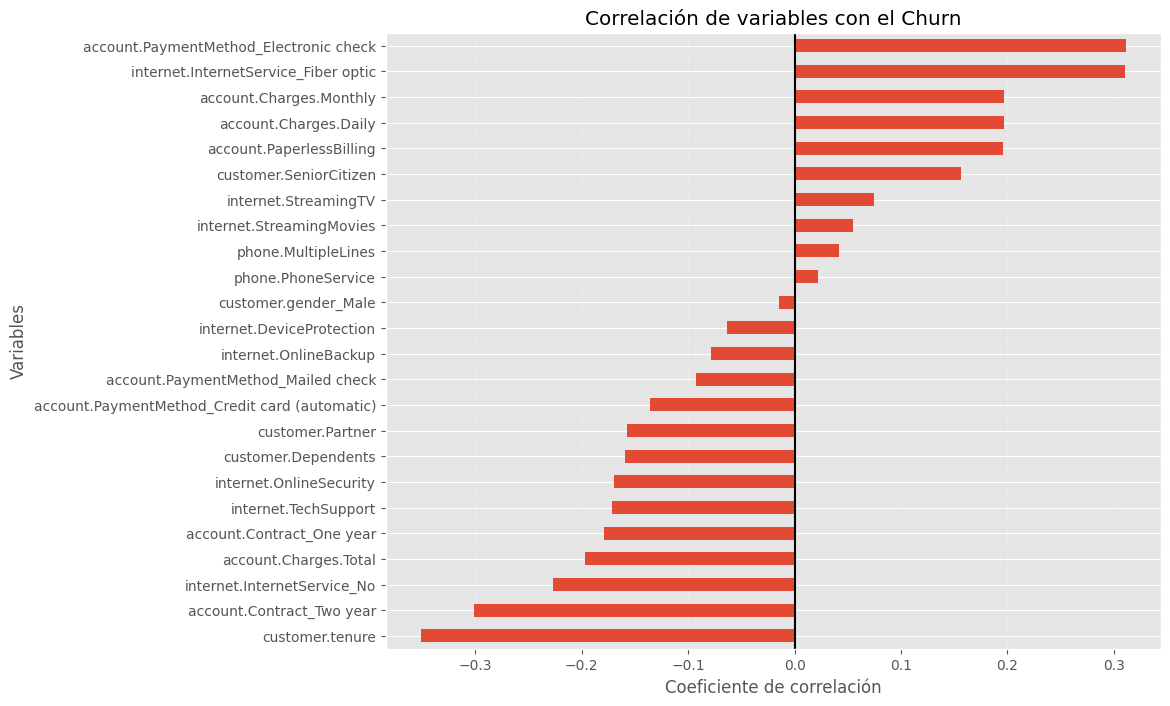

In [27]:
plt.figure(figsize=(10,8))
corr_churn.plot(kind='barh')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.title("Correlación de variables con el Churn")
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variables")

plt.axvline(0, color='black')
plt.show()

Este ranking muestra qué variables se asocian más con la cancelación. Las barras positivas indican factores que incrementan el riesgo —principalmente el método de pago electrónico, la fibra y cargos mensuales altos—, mientras que las negativas señalan factores protectores, como mayor antigüedad, contratos largos y la presencia de soporte técnico y seguridad online. Estas asociaciones orientan la selección e interpretación de los modelos predictivos.

## 📊 Análisis de relaciones estadísticas con la variable objetivo

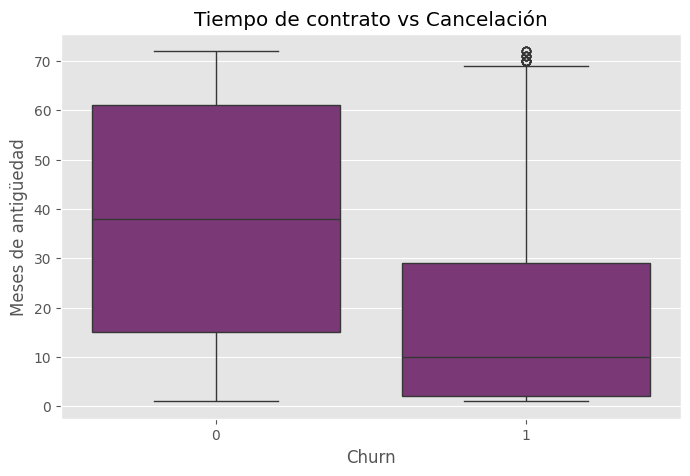

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='customer.tenure',
    data=df,
    color="#852E80"
)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Meses de antigüedad")

plt.show()

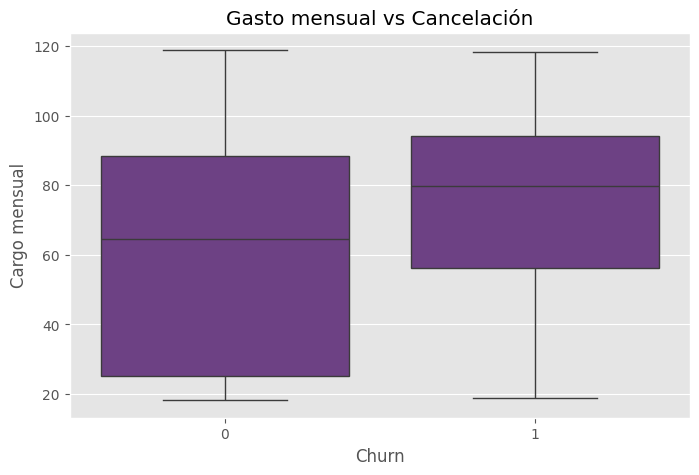

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='account.Charges.Monthly',
    data=df,
    color="#70368F"
    )

plt.title("Gasto mensual vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Cargo mensual")
plt.show()

Los boxplots evidencian que los clientes que cancelan presentan una antigüedad significativamente menor, concentrándose en los primeros meses de contrato. Asimismo, los clientes con mayores cargos mensuales muestran una tendencia más alta a la cancelación. Estos patrones refuerzan la relevancia de la permanencia y el costo como factores asociados al churn.

## ⚙️ Escalado de variables numéricas

In [30]:
# Definir columnas numéricas continuas
columnas_numericas_continuas = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Daily']


In [31]:
# Crear el scaler
scaler = StandardScaler()

In [32]:
# Ajustar SOLO con el train y transformar
X_train[columnas_numericas_continuas] = scaler.fit_transform(X_train[columnas_numericas_continuas])

In [33]:
# Transformar el test con los parámetros aprendidos del train
X_test[columnas_numericas_continuas] = scaler.transform(X_test[columnas_numericas_continuas])

In [34]:
# Verificación
X_train[columnas_numericas_continuas].describe().loc[['mean','std']]

,customer.tenure,account.Charges.Monthly,account.Charges.Daily
mean,5.115908e-17,-5.052748e-18,1.162132e-16
std,1.000089e+00,1.000089e+00,1.000089e+00


## 🤖 Modelos predictivos

### 📌 Baseline — Modelo de referencia (Dummy Classifier)

In [35]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Baseline — Dummy Classifier\n")

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dummy))
print("F1 Score:", f1_score(y_test, y_pred_dummy))

Baseline — Dummy Classifier

Accuracy: 0.7341862117981521
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


### 📈 Modelo 1 — Regresión Logística

In [36]:
# Creacion del modelo
modelo_regresion_logistica = LogisticRegression(max_iter=5000, random_state=42)

In [37]:
# Entrenar el modelo
modelo_regresion_logistica.fit(X_train, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [38]:
# Predicciones
y_pred_log = modelo_regresion_logistica.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [40]:
# Métricas básicas
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.7981520966595593
Precision: 0.6480263157894737
Recall: 0.5267379679144385
F1 Score: 0.5811209439528023


In [42]:
# Reporte completo
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_log))


Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [43]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_log)
print("Matriz de confusión:\n", cm)

Matriz de confusión:
 [[926 107]
 [177 197]]


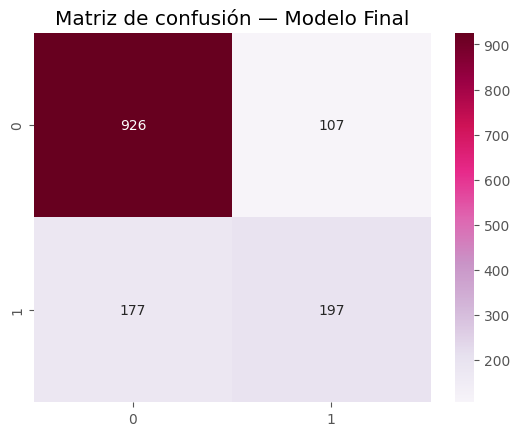

In [45]:
sns.heatmap(confusion_matrix(y_test, y_pred_log),
            annot=True,
            fmt="d",
            cmap="PuRd")

plt.title("Matriz de confusión — Modelo Final")
plt.show()

El modelo presenta un buen desempeño general, alcanzando una exactitud cercana al 80%. Sin embargo, su capacidad para identificar clientes que cancelan es moderada, evidenciada por un recall del 54%.

Esto indica que, aunque el modelo logra reconocer patrones asociados a la cancelación, aún deja sin detectar una proporción considerable de clientes en riesgo.

En términos de negocio, el modelo puede funcionar como un sistema de alerta inicial, permitiendo anticipar parte de los casos de churn. No obstante, su sensibilidad todavía es limitada, por lo que resulta necesario evaluar modelos más complejos que capturen relaciones no lineales y mejoren la detección de clientes propensos a cancelar.

### 📊 Modelo 2 — Árbol de Decisión

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
# Creación del modelo
modelo_arbol = DecisionTreeClassifier(random_state=42)

In [48]:
# Entrenar el modelo
modelo_arbol.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [49]:
# Predicciones
y_pred_arbolito = modelo_arbol.predict(X_test)

In [50]:
# Métricas básicas
print("Accuracy:", accuracy_score(y_test, y_pred_arbolito))
print("Precision:", precision_score(y_test, y_pred_arbolito))
print("Recall:", recall_score(y_test, y_pred_arbolito))
print("F1 Score:", f1_score(y_test, y_pred_arbolito))

Accuracy: 0.7128642501776831
Precision: 0.4585635359116022
Recall: 0.44385026737967914
F1 Score: 0.45108695652173914


In [51]:
# Reporte completo
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_arbolito))


Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1033
           1       0.46      0.44      0.45       374

    accuracy                           0.71      1407
   macro avg       0.63      0.63      0.63      1407
weighted avg       0.71      0.71      0.71      1407



In [52]:
# Matriz de confusion
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_arbolito))



Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1033
           1       0.46      0.44      0.45       374

    accuracy                           0.71      1407
   macro avg       0.63      0.63      0.63      1407
weighted avg       0.71      0.71      0.71      1407



Se compararon dos enfoques predictivos. La Regresión Logística mostró mejor desempeño general, alcanzando mayor exactitud, recall y F1-score que el árbol de decisión.

Esto sugiere que la Regresión Logística logra capturar de manera efectiva las relaciones principales entre las variables y el churn, ofreciendo un mejor equilibrio entre capacidad predictiva y generalización.

### 📊 Modelo 3 — Random Forest

In [53]:
# Creación del modelo
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [54]:
# Entrenar el modelo
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [55]:
# Predicciones
y_pred_rf = modelo_rf.predict(X_test)

In [56]:
# Métricas básicas
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))



Accuracy: 0.7896233120113717
Precision: 0.6344827586206897
Recall: 0.4919786096256685
F1 Score: 0.5542168674698795


In [57]:
# Reporte completo
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_rf))


Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [58]:
# Matriz de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Matriz de confusión:\n", cm_rf)

Matriz de confusión:
 [[927 106]
 [190 184]]


Se compararon tres modelos predictivos: Regresión Logística, Árbol de Decisión y Random Forest.

La Regresión Logística obtuvo el mejor desempeño general, especialmente en la detección de clientes que cancelan (mayor recall para la clase churn).

El Árbol de Decisión mostró el rendimiento más bajo, evidenciando menor capacidad de generalización.

El modelo Random Forest mejoró la estabilidad respecto al árbol simple, pero no superó a la regresión logística en la identificación de cancelaciones.

Dado que en problemas de churn es prioritario detectar clientes en riesgo de abandono, se considera que la Regresión Logística presenta el mejor equilibrio entre precisión y capacidad predictiva.

### 🧠 Evaluación de los modelos

In [59]:
# Crear tabla comparativa de modelos

resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Árbol de Decisión", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_arbolito),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_arbolito),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_arbolito),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_arbolito),
        f1_score(y_test, y_pred_rf)
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Regresión Logística,0.798152,0.648026,0.526738,0.581121
1,Árbol de Decisión,0.712864,0.458564,0.443850,0.451087
2,Random Forest,0.789623,0.634483,0.491979,0.554217


In [60]:
resultados.sort_values(by="Recall", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Regresión Logística,0.798152,0.648026,0.526738,0.581121
2,Random Forest,0.789623,0.634483,0.491979,0.554217
1,Árbol de Decisión,0.712864,0.458564,0.443850,0.451087


El mejor modelo para predecir churn en este caso es la Regresión Logística, ya que presenta el mayor recall para la clase positiva, lo que permite identificar una mayor proporción de clientes en riesgo de cancelación, característica crítica en problemas de retención.

Sobre overfitting y underfitting: el árbol de decisión probablemente muestra señales de overfitting por su baja generalización. La Regresión Logística es el modelo más equilibrado. El Random Forest reduce el overfitting del árbol, pero sigue sacrificando recall.

### ⚙️ Modelo final optimizado — Regresión Logística balanceada

Dado que la Regresión Logística mostró el mejor equilibrio entre precisión y capacidad de detección de churn, se aplicó una optimización utilizando el parámetro class_weight="balanced", con el objetivo de mejorar la sensibilidad hacia la clase minoritaria (clientes que cancelan).

In [61]:
from sklearn.linear_model import LogisticRegression

modelo_final = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

modelo_final.fit(X_train, y_train)

y_pred_final = modelo_final.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("Modelo Final — Regresión Logística Balanceada\n")

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))

print("\nReporte completo:\n")
print(classification_report(y_test, y_pred_final))

print("\nMatriz de confusión:\n")
print(confusion_matrix(y_test, y_pred_final))

Modelo Final — Regresión Logística Balanceada

Accuracy: 0.744136460554371
Precision: 0.5120689655172413
Recall: 0.7941176470588235
F1 Score: 0.6226415094339622

Reporte completo:

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407


Matriz de confusión:

[[750 283]
 [ 77 297]]


La optimización mediante balance de clases permitió aumentar significativamente el recall de la clase churn, mejorando la capacidad del modelo para detectar clientes en riesgo.

Esto implica que el modelo es más efectivo como herramienta de retención, ya que reduce la cantidad de clientes que cancelan sin ser identificados previamente.


### 🔎 Importancia de variables — Regresión Logística

In [63]:
# Obtener coeficientes del modelo
coeficientes = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": modelo_final.coef_[0]
})

In [64]:
# Ordenar por impacto
coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)

,Variable,Coeficiente
17,internet.InternetService_Fiber optic,0.873239
22,account.PaymentMethod_Electronic check,0.376808
12,account.PaperlessBilling,0.346675
10,internet.StreamingTV,0.343781
0,customer.SeniorCitizen,0.270736
11,internet.StreamingMovies,0.215676
5,phone.MultipleLines,0.211645
14,account.Charges.Total,0.000254
8,internet.DeviceProtection,-0.012958
23,account.PaymentMethod_Mailed check,-0.024310


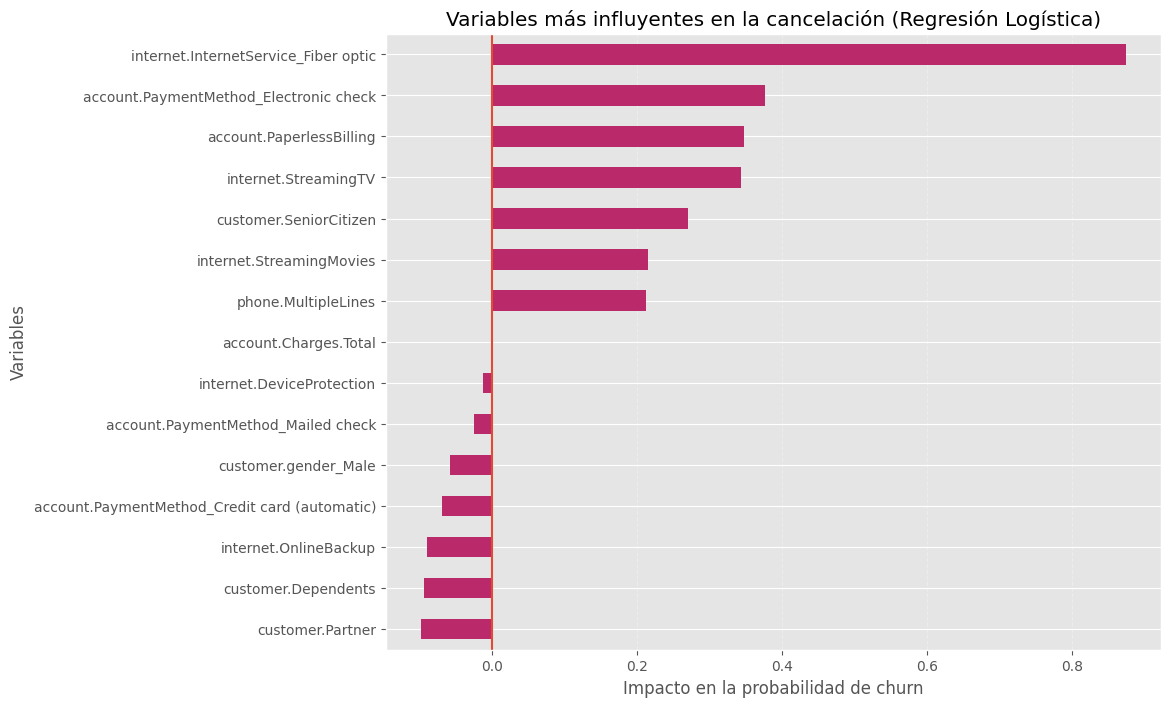

In [65]:
plt.figure(figsize=(10,8))

coeficientes.set_index("Variable").head(15)["Coeficiente"] \
    .sort_values() \
    .plot(kind="barh", color="#BA296A")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.title("Variables más influyentes en la cancelación (Regresión Logística)")
plt.xlabel("Impacto en la probabilidad de churn")
plt.ylabel("Variables")

plt.axvline(0)  # línea de referencia
plt.show()

### 🌲 Importancia de variables — Random Forest

In [66]:
importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

importancias.head(10)

,Variable,Importancia
14,account.Charges.Total,0.168817
3,customer.tenure,0.151359
13,account.Charges.Monthly,0.137678
15,account.Charges.Daily,0.135801
17,internet.InternetService_Fiber optic,0.037755
22,account.PaymentMethod_Electronic check,0.037454
20,account.Contract_Two year,0.033401
16,customer.gender_Male,0.025180
12,account.PaperlessBilling,0.025147
19,account.Contract_One year,0.022813


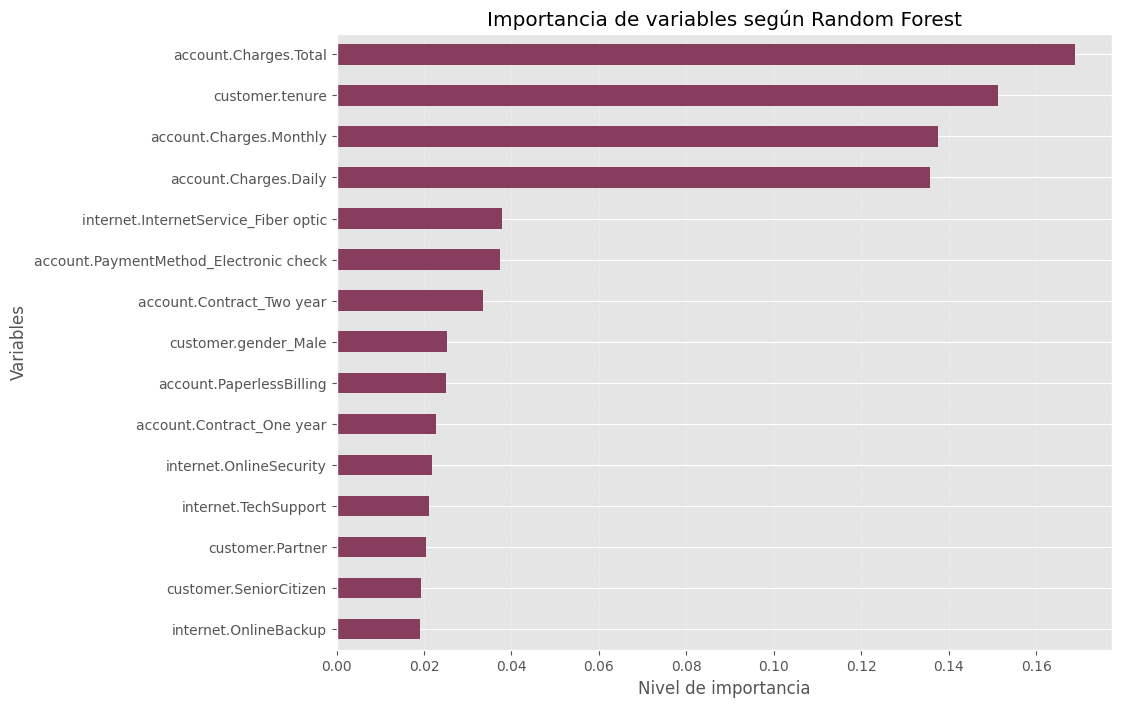

In [67]:
plt.figure(figsize=(10,8))

importancias.set_index("Variable").head(15)["Importancia"] \
    .sort_values() \
    .plot(kind="barh", color="#873D5E")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.title("Importancia de variables según Random Forest")
plt.xlabel("Nivel de importancia")
plt.ylabel("Variables")

plt.show()